## **Business Context**

Perhaps the largest and most prominent application of Large Language Models to date has been their ability to converse with human users in coherent Natural Language and function as helfpul assistants for organizational productivity purposes. As we know by now, a lot of work goes into creating and providing such Assistant-style LLMs to us as a service - the hugely compute-expensive Supervised Pre-training stage that's responsible for the vast majority of the LLM's world knowledge, the Instruction-style Supervised Fine-tuning stage on curated dialog datasets that adapts the LLM's behavior to that of a high-quality assistant, and the RLHF stage that teaches the LLM to provide responses that are aligned with human values. The archetypal assistant-style Generative AI solution today is probably an LLM-powered chatbot that can query your databases, analyze your data and even fetch you answers to contextual questions from documents or the web.

In this case study, we shall apply a Data Analysis / Data Science twist to this functionality. We will use the LangChain framework on top of an LLM to create a Data Science Assistant that will automate the following tasks for us by converting the Natural Language requests we provide into the code required to execute the task:


1. Data Analysis
2. Relational Database Querying


There are obvious reasons why such case study could be highly significant to business / research. By automating the code tasks common to various operations in Data Analysis, Data Science or Database Querying, such a solution has the potential to save significant time, improve code accuracy and also open up Data Analysis and Data Science to a more general audience that may not be familiar with the code involved.

From a broader perspective, the newfound ability of the best Large Language Models (beyond 1 billion parameters) to understand the true meaning of Natural Language commands and coherently respond to, acknowledge and fulfill them, has enabled us to usher in the next wave in the long list of automations that Computer Science has seen in its history. Translating commands into programming code, once solely the province of human developers, is now increasingly being automated by Generative AI, and we'll see many examples of the same in this project.

##**Case Study Objective**

The objective of this case study is to develop a Generative AI solution using the LangChain framework and a Large Language Model to automate tasks pertaining to Data Analysis, Data Science, Database Querying and Retrieval-Augmented Generation. This will be broken down into several sub-tasks, each of which will automatically be performed by our Large Language Model purely by prompting it in the right direction.

## Setting up the Environment

In [1]:
!pip install tiktoken==0.7.0;
!pip install openai==1.55.3;
!pip install pypdf==4.3.1;
!pip install faiss-gpu==1.7.2;
!pip install google_search_results==2.4.2;
!pip install cohere==5.6.2;
!pip install pandas==2.1.4;
!pip install matplotlib==3.7.1;
!pip install seaborn==0.13.1;
!pip install langchain-experimental==0.0.63 langchain==0.2.12 langchain-core==0.2.27

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.6/389.6 kB 10.6 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.76.0
    Uninstalling openai-1.76.0:
      Successfully uninstalled openai-1.76.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.8/295.8 kB 8.2 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement faiss-gpu==1.7.2 (from versions: none)
ERROR: No matching distribution found for faiss-gpu==1.7.2
  Preparing metadata (setup.py) ... done
  Created wheel for google_search_results: filename=google_search_results-2.4.2-py3-none-any.whl size=32010 sha256=a03b537abfd1ae4864b35aa699825ffdffb5dffb229ae5a378b5f3bc6f3f0390
  Stored in directory: /root/.cache/pip/wheels/6e/42/3e/aeb691b02cb7175ec70e2da04b5658d4739d2b41e5f73cd06f
Successfully built google_search_results
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.4/177.4 kB 7.1 MB/s eta 0:00:

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.13.2
    Uninstalling seaborn-0.13.2:
      Successfully uninstalled seaborn-0.13.2
INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of langchain-text-splitters to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.2/203.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 990.6/990.6 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.8/379.8 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [1]:
!pip install httpx==0.27.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: httpx
    Found existing installation: httpx 0.28.1
    Uninstalling httpx-0.28.1:
      Successfully uninstalled httpx-0.28.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 1.12.1 requires httpx<1.0.0,>=0.28.1, but you have httpx 0.27.2 which is incompatible.


In [2]:
!pip freeze > r.txt

In [4]:
# Importing libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from langchain_experimental.agents.agent_toolkits.pandas.base import create_pandas_dataframe_agent
from langchain.llms import OpenAI
from langchain.chat_models import ChatOpenAI
from langchain.agents.agent_types import AgentType
from langchain.sql_database import SQLDatabase
from langchain.llms import HuggingFacePipeline
from langchain.agents.agent_toolkits import SQLDatabaseToolkit
from langchain.llms import HuggingFaceHub
from langchain.document_loaders import PyPDFLoader
from langchain.document_loaders import UnstructuredPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain.embeddings import OpenAIEmbeddings
from langchain.agents.agent_toolkits import create_conversational_retrieval_agent
from langchain.agents.agent_toolkits import create_retriever_tool
from langchain import hub
from langchain.schema.runnable import RunnablePassthrough
from langchain.agents import load_tools
import sqlite3

In [17]:
from google.colab import userdata # Access user-specific data securely

# Retrieve the Open AI API key from user data
api_key = userdata.get('OPENAI_API_KEY')
endpoint = userdata.get('OPENAI_API_BASE')

In [18]:
llm = ChatOpenAI(
    model="gpt-4o",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=5,
    api_key=api_key,  # if you prefer to pass api key in directly instaed of using env vars
    base_url=endpoint
    )

## EDA Agent

<font color="#708090" style="font-size: 15px;"> **We are initialising a pandas dataframe agent below**
<font color="#708090" style="font-size: 15px;"> *What is an agent?*
>- <font color="#708090" style="font-size: 15px;"> It can be thought of as an interface with a variety of tools chained together. First do this, then do that ...
>- <font color="#708090" style="font-size: 15px;"> These tools are defined by users as prompts to the LLM. Connecting an agent with a LLM simply brings these tools into the arsenal of the LLM, enabling it to use them.
>- <font color="#708090" style="font-size: 15px;"> The role of the user is to provide the LLM with the tools through prompts, while the LLM is responsible for deciding which tools it must use depending on the user input.

<font color="#708090" style="font-size: 15px;"> Another thing to observe is that there can be as many agents as tools that you might create. So, an agent could search the web, could fetch weather data, could perform calculations, or even do machine learning!<br>
Below we are using a specialised tool which enables our LLM to deal with the pandas library (a widely used data management library for data science and machine learning)

In [20]:
# Importing the structured data. This could be any dataset of your choice, for now, let's work with some spotify data!
df = pd.read_csv('https://hastie.su.domains/ElemStatLearn/datasets/SAheart.data')

In [21]:
agent = create_pandas_dataframe_agent(llm, df, verbose=True,allow_dangerous_code=True, handle_parsing_errors=True,max_iterations = 34000, max_execution_time = 240.0)

/usr/local/lib/python3.11/dist-packages/langchain_experimental/agents/agent_toolkits/pandas/base.py:283: UserWarning: Received additional kwargs {'handle_parsing_errors': True} which are no longer supported.
  warnings.warn(


<font color="#708090" style="font-size: 15px;"> In the code above, we store our question in the text variable. The we simply 'run' the agent with this question. <br>
What this does is, it forwards this question to our LLM and let's it decide: "for this user question give me a response. Use pandas if you have to" <br>
You can quite clearly see the **chain of thought of the LLM**, this is our modelling reasoning with itself to answer our question. We can clearly see that the model feels that using the pandas library (which we provided through our agent) would be a good idea!

In [22]:
text = 'what are the different columns in the dataset ?'
agent.invoke(text)



> Entering new AgentExecutor chain...

Thought: To find the different columns in the dataset, I can use the `columns` attribute of the pandas DataFrame.
Action: python_repl_ast
Action Input: df.columns.tolist()['row.names', 'sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity', 'alcohol', 'age', 'chd']I now know the final answer.

Final Answer: The different columns in the dataset are: 'row.names', 'sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity', 'alcohol', 'age', 'chd'.

> Finished chain.


{'input': 'what are the different columns in the dataset ?',
 'output': "The different columns in the dataset are: 'row.names', 'sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity', 'alcohol', 'age', 'chd'."}

In [23]:
text = 'How many missing values are there in the dataset?'
agent.run(text)



> Entering new AgentExecutor chain...


/usr/local/lib/python3.11/dist-packages/langchain_core/_api/deprecation.py:139: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 0.3.0. Use invoke instead.
  warn_deprecated(


Thought: To determine the number of missing values in the dataset, I need to check for any null values in the dataframe and sum them up.
Action: python_repl_ast
Action Input: df.isnull().sum().sum()0I now know the final answer. There are no missing values in the dataset. 

Final Answer: There are 0 missing values in the dataset.

> Finished chain.


'There are 0 missing values in the dataset.'

In [24]:
text = 'what is the average obesity value?'
agent.run(text)



> Entering new AgentExecutor chain...
Thought: To find the average obesity value, I need to calculate the mean of the 'obesity' column in the dataframe `df`.
Action: python_repl_ast
Action Input: df['obesity'].mean()26.04411255411255I now know the final answer.
Final Answer: The average obesity value is approximately 26.04.

> Finished chain.


'The average obesity value is approximately 26.04.'

#  TOOK TIME

In [25]:
text = 'can you display a brief summary of the columns in the dataset for me?'
agent.run(text)



> Entering new AgentExecutor chain...
Thought: To display a brief summary of the columns in the dataset, I can use the `info()` method in pandas, which provides a concise summary of the DataFrame, including the column names, non-null counts, and data types.
Action: python_repl_ast
Action Input: df.info()<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   row.names  462 non-null    int64  
 1   sbp        462 non-null    int64  
 2   tobacco    462 non-null    float64
 3   ldl        462 non-null    float64
 4   adiposity  462 non-null    float64
 5   famhist    462 non-null    object 
 6   typea      462 non-null    int64  
 7   obesity    462 non-null    float64
 8   alcohol    462 non-null    float64
 9   age        462 non-null    int64  
 10  chd        462 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 39.8+ KB
I now

'The dataset contains 11 columns with the following details:\n- `row.names`: 462 non-null, int64\n- `sbp`: 462 non-null, int64\n- `tobacco`: 462 non-null, float64\n- `ldl`: 462 non-null, float64\n- `adiposity`: 462 non-null, float64\n- `famhist`: 462 non-null, object\n- `typea`: 462 non-null, int64\n- `obesity`: 462 non-null, float64\n- `alcohol`: 462 non-null, float64\n- `age`: 462 non-null, int64\n- `chd`: 462 non-null, int64\n\nThe dataset has a total of 462 entries, and the memory usage is approximately 39.8 KB.'

<font color="#708090" style="font-size: 15px;"> Observe how the Dataframe agent that we ran above not only gives us our answers, but it also gives us the code it used from the pandas library!

### Now that we have asked a few basic questions, let's ask the model to do some plotting for us

<font color="#708090" style="font-size: 15px;"> Alright, so we might want the model to do something more than just answering very basic questions about our data. Below we will see examples of how our dataframe agent can help us analyse the data in more detail

<font color="#708090" style="font-size: 15px;"> In the code cell below we do the following:
>- <font color="#708090" style="font-size: 15px;"> We got the model to plot a KDE plot for us for to help us find the relation between obesity and risk of heart disease. The KDE plot is simply a magical statistical tool which creates big hills in places with a lot of examples and steep valleys in places with very little examples.<br>
>- <font color="#708090" style="font-size: 15px;"> So from our understanding of KDE plots and obesity, we know the obese people are more prone to risk of heart disease. So that means the hill for people with heart disease (the blue hill) must be further to the right (more obesity) compared to the hill of people with no heart disease (green hill) and that is exactly what our model gives us!

In [30]:
agent = create_pandas_dataframe_agent(llm, df, verbose=True,allow_dangerous_code=True, handle_parsing_errors=True,max_iterations = 34000, max_execution_time = 240.0)

/usr/local/lib/python3.11/dist-packages/langchain_experimental/agents/agent_toolkits/pandas/base.py:283: UserWarning: Received additional kwargs {'handle_parsing_errors': True} which are no longer supported.
  warnings.warn(




> Entering new AgentExecutor chain...
To plot a KDE graph of obesity for people with CHD and without CHD using seaborn, we need to filter the dataframe based on the 'chd' column and then plot the KDE for the 'obesity' column. Let's proceed with the steps to achieve this.

Thought: I will use seaborn's `kdeplot` function to plot the KDE graph for the 'obesity' column, separating the data based on the 'chd' column. I will first import the necessary libraries and then create the plot.

Action: Import the necessary libraries and plot the KDE graph.
Action Input:
```python
import seaborn as sns
import matplotlib.pyplot as plt

# Plot KDE for obesity with CHD
sns.kdeplot(data=df[df['chd'] == 1], x='obesity', label='CHD', fill=True)

# Plot KDE for obesity without CHD
sns.kdeplot(data=df[df['chd'] == 0], x='obesity', label='No CHD', fill=True)

# Add labels and legend
plt.xlabel('Obesity')
plt.ylabel('Density')
plt.title('KDE of Obesity for People with and without CHD')
plt.legend()
plt.sho

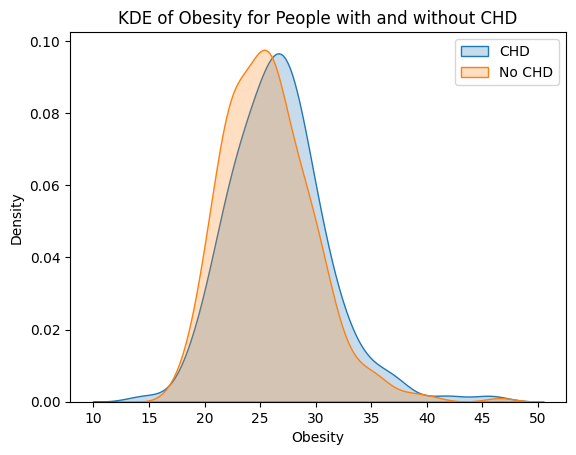

I have successfully plotted the KDE graph of obesity for people with CHD and without CHD using seaborn. The graph displays the density distribution of obesity for both groups, allowing for a visual comparison.

Final Answer: The KDE graph of obesity for people with CHD and without CHD has been plotted using seaborn.

> Finished chain.
The KDE graph of obesity for people with CHD and without CHD has been plotted using seaborn.


In [46]:
response = agent.run("Plot a KDE graph of obesity for people with CHD and without CHD using seaborn.")
print(response)

<font color="#708090" style="font-size: 16px;"> Now we do the same to find how heart disease is related with hills. The regions where the bars become taller contain more people. We know that older people are more prone to heart diease, and guess what, that is exactly what our model shows us!



> Entering new AgentExecutor chain...
Thought: To show the distribution of age for people with coronary heart disease (chd), I will filter the dataframe for rows where `chd` is 1, and then plot a histogram of the `age` column. I will label the axes accordingly.

Action: python_repl_ast
Action Input: 
```python
import matplotlib.pyplot as plt

# Filter the dataframe for people with chd
chd_df = df[df['chd'] == 1]

# Plot the distribution of age
plt.hist(chd_df['age'], bins=10, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age for People with CHD')
plt.show()
```

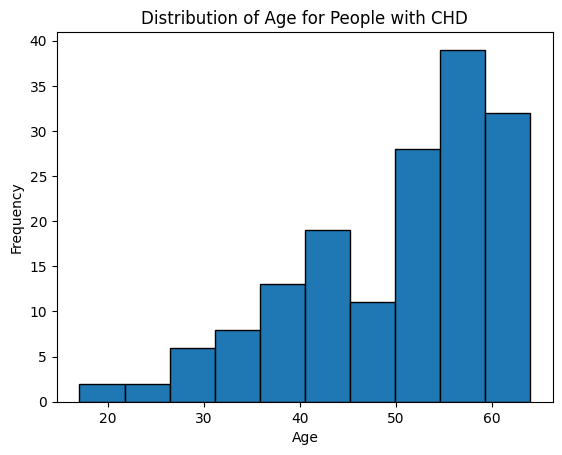

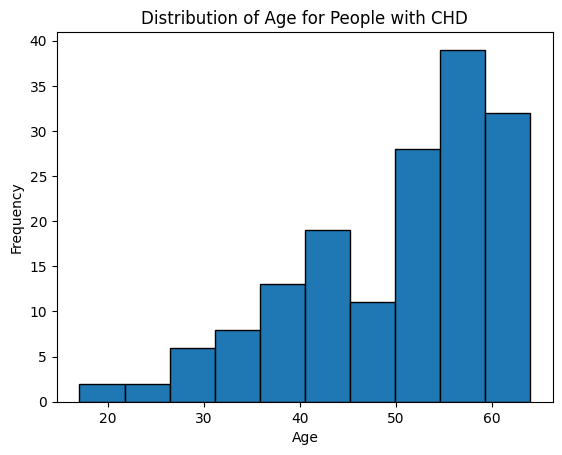

I forgot to execute the code to observe the histogram. Let me do that now to see the distribution of age for people with CHD.

Action: python_repl_ast
Action Input: 
```python
import matplotlib.pyplot as plt

# Filter the dataframe for people with chd
chd_df = df[df['chd'] == 1]

# Plot the distribution of age
plt.hist(chd_df['age'], bins=10, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age for People with CHD')
plt.show()
```I have plotted the histogram showing the distribution of age for people with coronary heart disease (CHD). 

Final Answer: The histogram shows the distribution of age for people with CHD. The x-axis is labeled "Age" and the y-axis is labeled "Frequency". The principal trend observed is that the frequency of CHD cases tends to increase with age, indicating that older individuals are more likely to have CHD.

> Finished chain.


'The histogram shows the distribution of age for people with CHD. The x-axis is labeled "Age" and the y-axis is labeled "Frequency". The principal trend observed is that the frequency of CHD cases tends to increase with age, indicating that older individuals are more likely to have CHD.'

In [32]:
text= """show distribution of age of people with chd. Label the axes. Finally comment on the principal trend observed."""
agent.run(text)

<font color="#708090" style="font-size: 16px;"> What if we would like to see how the various factors contributing towards heart dieases are related to each other ? We can do this by plotting a heatmap where darker colored tiles mean that the factors corresponding to row and column position of the tile are heavily related and lighter colors show a lighter relation



> Entering new AgentExecutor chain...
To draw a heatmap to show the correlation between all the columns in the dataframe `df`, we can use the `seaborn` library, which provides a convenient function `heatmap` for this purpose. We will first calculate the correlation matrix using the `corr` method of the dataframe, and then plot it using `seaborn.heatmap`.

Let's proceed with these steps:

1. Import the necessary libraries.
2. Calculate the correlation matrix.
3. Plot the heatmap.

Action: python_repl_ast
Action Input: 
```python
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()
```ValueError: could not convert string to float: 'Present'The error indicates that there is a non-numeric column in the dataframe, specifically the 'famhist' column, which contai

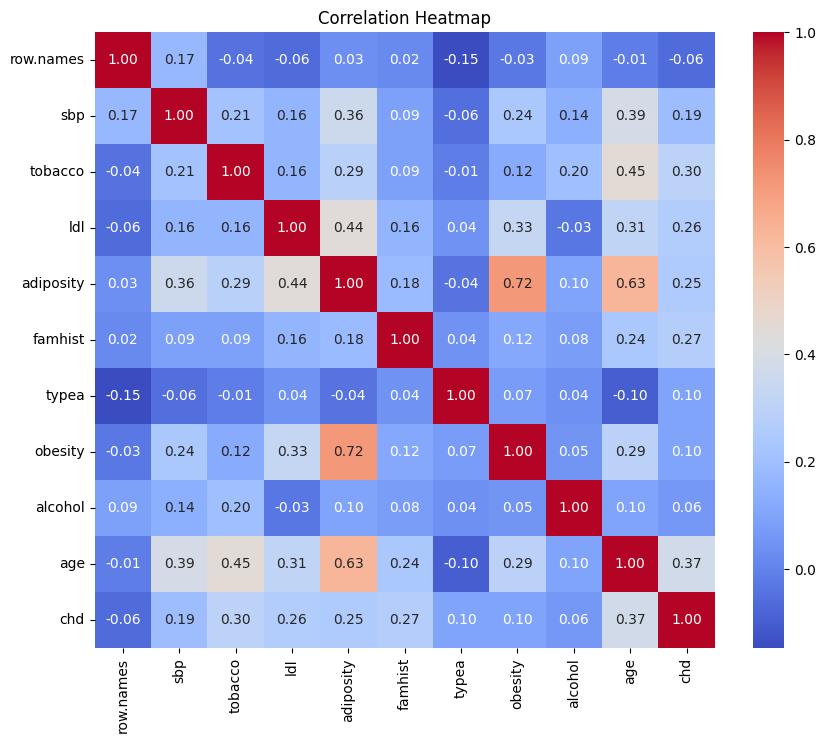

The heatmap has been successfully plotted, showing the correlation between all the columns in the dataframe. 

Final Answer: The heatmap displays the correlation between the columns in the dataframe. Strong positive correlations are shown in darker shades of red, while strong negative correlations are shown in darker shades of blue. The diagonal of the heatmap will always show a perfect correlation of 1.0, as each variable is perfectly correlated with itself. The trend in the heatmap can help identify which variables have strong relationships with each other, which can be useful for further analysis or feature selection.

> Finished chain.


'The heatmap displays the correlation between the columns in the dataframe. Strong positive correlations are shown in darker shades of red, while strong negative correlations are shown in darker shades of blue. The diagonal of the heatmap will always show a perfect correlation of 1.0, as each variable is perfectly correlated with itself. The trend in the heatmap can help identify which variables have strong relationships with each other, which can be useful for further analysis or feature selection.'

In [33]:
agent.run('Draw heatmap to show correlation between all the columns. Summarize the trend')

## Database Natural Language Querying

<font color="#708090" style="font-size: 16px;"> In this section, we will be focusing on using a new agent with out LLM.<br> This agent will do 2 main things for us:<br>
- <font color="#708090" style="font-size: 16px;"> It will query a database
    >-<font color="#708090" style="font-size: 16px;"> Think of amazon, they have millions of customers and millions of products. Where do they store the information? They store it in a database. So being able to find relevant information from the database is very crucial and is done through queries (requests). Our agent will now do this for us!
    >- <font color="#708090" style="font-size: 16px;"> Secondly, we will also equip our agent with another tool - maths. Normally, LLMs are not too good at math, however, you will now see that adding a math tool will make our LLM much better.

In [34]:
from langchain.agents import *
from langchain.sql_database import SQLDatabase
from langchain.llms import HuggingFacePipeline

<font color="#708090" style="font-size: 16px;"> We are just creating a toy database. This could be something much larger and much more sophisticated too

In [35]:
# Creating a dummy SQL database for our example. If you have a database file on hand, you can skip this part
conn = sqlite3.connect('sample.db')
# Create a cursor object to interact with the database
cursor = conn.cursor()

# Create a table to store employee information
cursor.execute('''
    CREATE TABLE IF NOT EXISTS Employees (
        EmployeeID INTEGER PRIMARY KEY,
        FirstName TEXT,
        LastName TEXT,
        Birthdate DATE,
        Department TEXT,
        Salary REAL
    )
''')

# Insert some sample data into the Employees table
cursor.executemany('''
    INSERT INTO Employees (FirstName, LastName, Birthdate, Department, Salary)
    VALUES (?, ?, ?, ?, ?)
''', [
    ('John', 'Doe', '1990-05-15', 'HR', 50000.00),
    ('Jane', 'Smith', '1985-12-10', 'Sales', 55000.00),
    ('Bob', 'Johnson', '1992-08-25', 'Engineering', 60000.00),
    ('Alice', 'Brown', '1988-04-03', 'Marketing', 52000.00)
])

# Commit the changes and close the connection
conn.commit()
conn.close()

In [36]:
# In place of file, you can enter the path to your database file
file = "sample.db"
db = SQLDatabase.from_uri(f"sqlite:///{file}")

<font color="#708090" style="font-size: 16px;"> Here we are creating our database agent and equipping it with the math tool :)

In [37]:
tools = ['llm-math']

In [38]:
tools = load_tools(tools,llm)

In [39]:
toolkit = SQLDatabaseToolkit(db=db, llm=llm)
db_agent = create_sql_agent(
    llm=llm,
    toolkit=toolkit,
    tools = tools,
    verbose=True
)

<font color="#708090" style="font-size: 16px;"> Now in the same manner as in the previous section, we can ask our agent questions and wait for its response. There is not much difference in the format of the response however the underlying operations are vastly different.

In [40]:
# agent_executor.run("Describe the Order related table and how they are related")
db_agent.run("Name the columns present in the database?")



> Entering new SQL Agent Executor chain...
Action: sql_db_list_tables
Action Input: ""EmployeesThe database contains a table named "Employees". I should query the schema of this table to find out the columns present in it. 
Action: sql_db_schema
Action Input: Employees
CREATE TABLE "Employees" (
	"EmployeeID" INTEGER, 
	"FirstName" TEXT, 
	"LastName" TEXT, 
	"Birthdate" DATE, 
	"Department" TEXT, 
	"Salary" REAL, 
	PRIMARY KEY ("EmployeeID")
)

/*
3 rows from Employees table:
EmployeeID	FirstName	LastName	Birthdate	Department	Salary
1	John	Doe	1990-05-15	HR	50000.0
2	Jane	Smith	1985-12-10	Sales	55000.0
3	Bob	Johnson	1992-08-25	Engineering	60000.0
*/I now know the final answer.

Final Answer: The "Employees" table has the following columns: EmployeeID, FirstName, LastName, Birthdate, Department, and Salary.

> Finished chain.


'The "Employees" table has the following columns: EmployeeID, FirstName, LastName, Birthdate, Department, and Salary.'

In [41]:
db_agent.run("What was the maximum salary paid to an employee ? To whom was it paid?")



> Entering new SQL Agent Executor chain...
Action: sql_db_list_tables
Action Input: ""EmployeesThe table "Employees" likely contains information about employees, including their salaries. I should check the schema of the "Employees" table to identify the relevant columns for this query. 
Action: sql_db_schema
Action Input: Employees
CREATE TABLE "Employees" (
	"EmployeeID" INTEGER, 
	"FirstName" TEXT, 
	"LastName" TEXT, 
	"Birthdate" DATE, 
	"Department" TEXT, 
	"Salary" REAL, 
	PRIMARY KEY ("EmployeeID")
)

/*
3 rows from Employees table:
EmployeeID	FirstName	LastName	Birthdate	Department	Salary
1	John	Doe	1990-05-15	HR	50000.0
2	Jane	Smith	1985-12-10	Sales	55000.0
3	Bob	Johnson	1992-08-25	Engineering	60000.0
*/The "Employees" table contains the "Salary" column, which I can use to find the maximum salary. I will also need the "FirstName" and "LastName" columns to identify the employee who received this salary. I will construct a query to find the maximum salary and the corresponding

'The maximum salary paid to an employee was 60,000, and it was paid to Bob Johnson.'

<font color="#708090" style="font-size: 16px;"> Look how well the LLM does while finding the sqaure root! I wish I could equip myself with the math tool :(

In [42]:
# Now lets see if our LLM is profecient at arithemtic too
db_agent.run('can you find the square root of the maximum salary paid to an employee?')



> Entering new SQL Agent Executor chain...
Action: sql_db_list_tables
Action Input: ""EmployeesThe table "Employees" likely contains information about employee salaries. I should check the schema of the "Employees" table to find the relevant column for salaries.

Action: sql_db_schema
Action Input: Employees
CREATE TABLE "Employees" (
	"EmployeeID" INTEGER, 
	"FirstName" TEXT, 
	"LastName" TEXT, 
	"Birthdate" DATE, 
	"Department" TEXT, 
	"Salary" REAL, 
	PRIMARY KEY ("EmployeeID")
)

/*
3 rows from Employees table:
EmployeeID	FirstName	LastName	Birthdate	Department	Salary
1	John	Doe	1990-05-15	HR	50000.0
2	Jane	Smith	1985-12-10	Sales	55000.0
3	Bob	Johnson	1992-08-25	Engineering	60000.0
*/The "Employees" table contains a "Salary" column, which is relevant for finding the maximum salary. I need to calculate the square root of the maximum salary from this table.

Action: sql_db_query_checker
Action Input: SELECT SQRT(MAX(Salary)) AS MaxSalarySqrt FROM Employees;```sql
SELECT SQRT(MAX(Sa

'The square root of the maximum salary paid to an employee is approximately 244.95.'